<a href="https://colab.research.google.com/github/pxtroniwnl/barcelona-de-indias-time-serie/blob/main/temperaturaIDEAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Temperatura del aire — estaciones IDEAM cercanas al ROI de la laguna

**Fuente:** CSV del IDEAM, departamento de Bolívar, sensor de temperatura del aire a 2 m.
**Objetivo:** Identificar las 2 estaciones más cercanas al ROI de la laguna Barcelona de Indias, limpiar y homogenizar sus series de tiempo y exportarlas para análisis posteriores.

## 1. Configuración

In [1]:
import csv
import io
import math
from pathlib import Path

import folium
from folium.plugins import Fullscreen
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Rutas locales
RUTA_CSV = Path("data/ideam/Temperatura_Ambiente_del_Aire_20260818_SOLO_BOLIVAR.csv")

# Formato de fecha del IDEAM
FORMATO_FECHA = "%Y %b %d %I:%M:%S %p"

# Conservar como texto para no perder ceros a la izquierda en códigos
DTYPES_TEXTO = {"CodigoEstacion": "string", "CodigoSensor": "string"}

COLS_TEXTO = [
    "CodigoEstacion", "CodigoSensor", "NombreEstacion", "Departamento",
    "Municipio", "ZonaHidrografica", "DescripcionSensor", "UnidadMedida",
]

# Rango físicamente plausible para temperatura del aire en el Caribe colombiano (°C)
RANGO_TEMP_VALIDO = (5.0, 50.0)

# ROI de la laguna Barcelona de Indias (longitud, latitud)
ROI_COORDS = [
    [-75.476052, 10.517524],
    [-75.476117, 10.518747],
    [-75.473158, 10.519223],
    [-75.470516, 10.525108],
    [-75.469572, 10.524876],
    [-75.471686, 10.518916],
    [-75.468394, 10.517219],
    [-75.468952, 10.516459],
]

FACTORES = [1, 2, 3, 4]
COLORES_CAJA = {1: "red", 2: "orange", 3: "gold", 4: "green"}
N_ESTACIONES = 2
TOL_SITIO = 3  # decimales de redondeo para colapsar sitios físicos (≈ 110 m)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

## 2. Carga del CSV crudo

Se carga directamente utilizando el motor C optimizado de `pandas`.
`df_raw` **no se modifica nunca**.

In [2]:
def cargar_crudo(ruta: Path) -> pd.DataFrame:
    """Carga el CSV del IDEAM de forma directa y eficiente en memoria."""
    return pd.read_csv(ruta, dtype=DTYPES_TEXTO, encoding="utf-8-sig", low_memory=False)


df_raw = cargar_crudo(RUTA_CSV)
print(f"{len(df_raw):,} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)

1,229,593 filas × 12 columnas


,CodigoEstacion,CodigoSensor,FechaObservacion,ValorObservado,NombreEstacion,Departamento,Municipio,ZonaHidrografica,Latitud,Longitud,DescripcionSensor,UnidadMedida
0,0029015000,0068,2020 Jan 21 09:00:00 PM,36.2,EL GUAMO - AUT,BOLIVAR,EL GUAMO,BAJO MAGDALENA,10.064444,-74.852222,Temp Aire 2 m,°C
1,0029015000,0068,2020 Jan 21 06:00:00 AM,34.4,EL GUAMO - AUT,BOLIVAR,EL GUAMO,BAJO MAGDALENA,10.064444,-74.852222,Temp Aire 2 m,°C
2,0029015000,0068,2020 Jan 21 08:00:00 AM,36.2,EL GUAMO - AUT,BOLIVAR,EL GUAMO,BAJO MAGDALENA,10.064444,-74.852222,Temp Aire 2 m,°C


In [3]:
# Diagnóstico del crudo: valores categóricos y encoding
for col in ["UnidadMedida", "DescripcionSensor", "CodigoSensor", "Departamento"]:
    vals = sorted(df_raw[col].dropna().unique().tolist())
    print(f"{col:20s} ({len(vals):>3}): {vals[:6]}{' …' if len(vals) > 6 else ''}")

print()
print(df_raw.dtypes)

UnidadMedida         (  1): ['°C']


DescripcionSensor    (  3): ['GPRS - TEMPERATURA DEL AIRE A 2 m', 'TEMPERATURA DEL AIRE A 2 m', 'Temp Aire 2 m']
CodigoSensor         (  2): ['0068', '0071']


Departamento         (  3): ['BOLIVAR', 'BOLÍVAR', 'Bolivar']

CodigoEstacion        string
CodigoSensor          string
FechaObservacion         str
ValorObservado       float64
NombreEstacion           str
Departamento             str
Municipio                str
ZonaHidrografica         str
Latitud              float64
Longitud             float64
DescripcionSensor        str
UnidadMedida             str
dtype: object


## 3. Limpieza

Cuatro operaciones deterministas:
1. Normalización de texto en columnas categóricas.
2. Parseo estricto de fecha y hora.
3. Control de rango físico (valores fuera de 5 a 50 °C se marcan como NaN).
4. Desduplicación por `(CodigoEstacion, FechaObservacion)`.

In [4]:
def limpiar(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Normaliza texto, parsea fechas, filtra valores implausibles y desduplica."""
    df = df_raw.copy()

    # 1. texto: extremos + espacios internos colapsados
    for c in COLS_TEXTO:
        if c in df.columns:
            df[c] = df[c].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)

    # 2. fecha
    df["FechaObservacion"] = pd.to_datetime(df["FechaObservacion"], format=FORMATO_FECHA, errors="coerce")

    # 3. rango físico → NaN (no se borra la fila)
    lo, hi = RANGO_TEMP_VALIDO
    df["ValorObservado"] = pd.to_numeric(df["ValorObservado"], errors="coerce")
    df.loc[~df["ValorObservado"].between(lo, hi), "ValorObservado"] = np.nan

    # 4. desduplicación determinista
    df = (
        df.sort_values(["CodigoEstacion", "FechaObservacion", "CodigoSensor"], kind="stable")
        .drop_duplicates(subset=["CodigoEstacion", "FechaObservacion"], keep="first")
        .reset_index(drop=True)
    )
    return df


df = limpiar(df_raw)

print(f"crudo   : {len(df_raw):,}")
print(f"limpio  : {len(df):,}  ({len(df_raw) - len(df):,} duplicados eliminados)")
print(f"NaN QC  : {df['ValorObservado'].isna().sum():,} valores fuera de {RANGO_TEMP_VALIDO}")
df.dtypes

crudo   : 1,229,593
limpio  : 1,087,677  (141,916 duplicados eliminados)
NaN QC  : 340 valores fuera de (5.0, 50.0)


CodigoEstacion               string
CodigoSensor                 string
FechaObservacion     datetime64[us]
ValorObservado              float64
NombreEstacion               string
Departamento                 string
Municipio                    string
ZonaHidrografica             string
Latitud                     float64
Longitud                    float64
DescripcionSensor            string
UnidadMedida                 string
dtype: object

## 4. Catálogo de estaciones

Se construye un catálogo determinista con un nombre canónico y coordenadas representativas por estación.

In [5]:
def construir_catalogo(df: pd.DataFrame) -> pd.DataFrame:
    """Una fila por CodigoEstacion, con nombre canónico y coordenadas robustas."""
    conteo = (
        df.groupby(["CodigoEstacion", "NombreEstacion"], as_index=False)
        .size()
        .rename(columns={"size": "_n"})
    )
    nombre_canonico = (
        conteo.sort_values(
            ["CodigoEstacion", "_n", "NombreEstacion"],
            ascending=[True, False, True],
            kind="stable",
        )
        .drop_duplicates("CodigoEstacion", keep="first")
        .drop(columns="_n")
    )

    agregados = (
        df.groupby("CodigoEstacion")
        .agg(
            Municipio=("Municipio", lambda s: s.mode().iat[0]),
            ZonaHidrografica=("ZonaHidrografica", lambda s: s.mode().iat[0]),
            Latitud=("Latitud", "median"),
            Longitud=("Longitud", "median"),
            n_variantes_nombre=("NombreEstacion", "nunique"),
            n_sensores=("CodigoSensor", "nunique"),
            n_obs=("ValorObservado", "size"),
        )
        .reset_index()
    )

    return nombre_canonico.merge(agregados, on="CodigoEstacion", how="left")


catalogo = construir_catalogo(df)
print(f"{len(catalogo)} estaciones únicas en el departamento de Bolívar")
catalogo.sort_values("n_obs", ascending=False).head(10)

13 estaciones únicas en el departamento de Bolívar


,CodigoEstacion,NombreEstacion,Municipio,ZonaHidrografica,Latitud,Longitud,n_variantes_nombre,n_sensores,n_obs
2,0014015080,AEROPUERTO RAFAEL NUNEZ,CARTAGENA DE INDIAS,CARIBE - LITORAL,10.447250,-75.516028,2,2,599105
9,0029015040,CARMEN DE BOLIVAR - AUT,EL CARMÉN DE BOLÍVAR,BAJO MAGDALENA,9.715750,-75.106417,3,1,84349
8,0029015000,EL GUAMO - AUT,EL GUAMO,BAJO MAGDALENA,10.064444,-74.852222,3,1,79625
10,0029035000,SINCERIN - AUT,ARJONA,BAJO MAGDALENA,10.142583,-75.278278,3,1,75202
3,0014017001,TESORO INVEMAR,CARTAGENA DE INDIAS,BAJO MAGDALENA,10.235000,-75.741000,1,1,50658
1,0014015020,APTO RAFAEL NUÑEZ TX GPRS,CARTAGENA,CARIBE - LITORAL,10.447000,-75.516000,1,1,40676
11,1206500136,UNIVERSIDAD UNAD CARTAGENA - AUT,CARTAGENA DE INDIAS,CARIBE - LITORAL,10.400311,-75.513281,3,1,34624
6,0025025100,AEROPUERTO BARACOA,MAGANGUÉ,BAJO MAGDALENA- CAUCA -SAN JORGE,9.281944,-74.845278,2,1,29792
12,2901500072,HOBO,EL CARMÉN DE BOLÍVAR,BAJO MAGDALENA,9.672419,-75.236458,3,1,26974
5,0023205050,CANELOS - AUT,SANTA ROSA DEL SUR,MEDIO MAGDALENA,7.885417,-74.240972,1,1,22958


## 5. Geometría: ROI y cajas anidadas

In [6]:
# Centro y semiejes del bounding box del ROI (cálculo local)
_lons = [c[0] for c in ROI_COORDS]
_lats = [c[1] for c in ROI_COORDS]
CX, CY = (min(_lons) + max(_lons)) / 2, (min(_lats) + max(_lats)) / 2
HW, HH = (max(_lons) - min(_lons)) / 2, (max(_lats) - min(_lats)) / 2

BBOXES = {f: (CX - HW * f, CY - HH * f, CX + HW * f, CY + HH * f) for f in FACTORES}

print(f"Centro del ROI: lat={CY:.6f}, lon={CX:.6f}\n")
for f in FACTORES:
    x0, y0, x1, y1 = BBOXES[f]
    ancho = (x1 - x0) * 111.32 * math.cos(math.radians(CY))
    alto = (y1 - y0) * 111.32
    print(f"  {f}x → {ancho:5.2f} km × {alto:5.2f} km   (área ≈ {ancho*alto:5.2f} km²)")

Centro del ROI: lat=10.520784, lon=-75.472256

  1x →  0.85 km ×  0.96 km   (área ≈  0.81 km²)
  2x →  1.69 km ×  1.93 km   (área ≈  3.26 km²)
  3x →  2.54 km ×  2.89 km   (área ≈  7.32 km²)
  4x →  3.38 km ×  3.85 km   (área ≈ 13.02 km²)


## 6. Clasificación espacial y distancias

Cálculo de distancias esféricas (Haversine) al centro del ROI y distancia mínima euclidiana proyectada al perímetro del polígono ROI.

In [7]:
def dist_haversine_km(lat, lon, lat0: float, lon0: float, R: float = 6371.0088) -> np.ndarray:
    """Distancia esférica desde cada punto hasta (lat0, lon0), en km. Vectorizada."""
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    dphi = np.radians(lat0 - lat)
    dlam = np.radians(lon0 - lon)
    a = (
        np.sin(dphi / 2) ** 2
        + np.cos(np.radians(lat)) * math.cos(math.radians(lat0)) * np.sin(dlam / 2) ** 2
    )
    return 2 * R * np.arcsin(np.sqrt(a))


def clasificar_por_caja(df: pd.DataFrame) -> pd.Series:
    """Nivel de la caja más pequeña que contiene el punto; <NA> si ninguna."""
    nivel = pd.Series(pd.NA, index=df.index, dtype="Int32")
    for f in sorted(FACTORES, reverse=True):
        x0, y0, x1, y1 = BBOXES[f]
        dentro = df["Longitud"].between(x0, x1) & df["Latitud"].between(y0, y1)
        nivel = nivel.mask(dentro, f)
    return nivel


def _xy_local(lon, lat):
    km_lat = 111.32
    km_lon = 111.32 * math.cos(math.radians(CY))
    return np.array([(lon - CX) * km_lon, (lat - CY) * km_lat], dtype=float)


def _dist_punto_segmento(p, a, b) -> float:
    ab = b - a
    den = float(np.dot(ab, ab))
    t = 0.0 if den == 0 else float(np.clip(np.dot(p - a, ab) / den, 0, 1))
    return float(np.linalg.norm(p - (a + t * ab)))


def dist_borde_roi_km(lat: float, lon: float) -> float:
    coords = ROI_COORDS + [ROI_COORDS[0]]
    p = _xy_local(lon, lat)
    return min(
        _dist_punto_segmento(p, _xy_local(*coords[i]), _xy_local(*coords[i + 1]))
        for i in range(len(coords) - 1)
    )


estaciones = catalogo.copy()
estaciones["nivel_caja"] = clasificar_por_caja(estaciones)
estaciones["dist_km"] = dist_haversine_km(
    estaciones["Latitud"], estaciones["Longitud"], CY, CX
).round(2)
estaciones["d_borde_km"] = estaciones.apply(
    lambda r: round(dist_borde_roi_km(r["Latitud"], r["Longitud"]), 2), axis=1
)
estaciones = estaciones.sort_values("dist_km", kind="stable").reset_index(drop=True)

n_dentro = int(estaciones["nivel_caja"].notna().sum())
print(f"Estaciones dentro de alguna caja: {n_dentro}")
print(f"Estación más cercana: {estaciones['dist_km'].iat[0]:.2f} km al centro, {estaciones['d_borde_km'].iat[0]:.2f} km al borde\n")

estaciones[["CodigoEstacion", "NombreEstacion", "Municipio", "nivel_caja", "dist_km", "d_borde_km", "n_obs"]].head(10)

Estaciones dentro de alguna caja: 0
Estación más cercana: 9.47 km al centro, 8.96 km al borde



,CodigoEstacion,NombreEstacion,Municipio,nivel_caja,dist_km,d_borde_km,n_obs
0,0014015080,AEROPUERTO RAFAEL NUNEZ,CARTAGENA DE INDIAS,<NA>,9.47,8.96,599105
1,0014015020,APTO RAFAEL NUÑEZ TX GPRS,CARTAGENA,<NA>,9.50,8.99,40676
2,1206500136,UNIVERSIDAD UNAD CARTAGENA - AUT,CARTAGENA DE INDIAS,<NA>,14.13,13.67,34624
3,0014015010,GALERAZAMBA,SANTA CATALINA,<NA>,38.20,37.71,11746
4,0014017001,TESORO INVEMAR,CARTAGENA DE INDIAS,<NA>,43.29,42.78,50658
5,0029035000,SINCERIN - AUT,ARJONA,<NA>,47.10,46.56,75202
6,0029015000,EL GUAMO - AUT,EL GUAMO,<NA>,84.71,84.19,79625
7,2901500072,HOBO,EL CARMÉN DE BOLÍVAR,<NA>,97.80,97.34,26974
8,0029015040,CARMEN DE BOLIVAR - AUT,EL CARMÉN DE BOLÍVAR,<NA>,98.07,97.57,84349
9,0025025100,AEROPUERTO BARACOA,MAGANGUÉ,<NA>,153.92,153.45,29792


### Sitios físicos únicos

Se colapsan estaciones que corresponden a un mismo punto geográfico (por ejemplo, transmisiones convencional y GPRS en el mismo aeropuerto).

In [8]:
def colapsar_sitios(estaciones: pd.DataFrame, tol: int = TOL_SITIO) -> pd.DataFrame:
    """Colapsa entradas de catálogo que corresponden al mismo sitio físico."""
    e = estaciones.sort_values("dist_km", kind="stable").copy()
    e["_la"] = e["Latitud"].round(tol)
    e["_lo"] = e["Longitud"].round(tol)

    g = e.groupby(["_la", "_lo"])["CodigoEstacion"]
    e["n_entradas_catalogo"] = g.transform("size")
    e["codigos_del_sitio"] = g.transform(lambda s: [list(s)] * len(s))

    return (
        e.drop_duplicates(["_la", "_lo"], keep="first")
        .drop(columns=["_la", "_lo"])
        .reset_index(drop=True)
    )


sitios = colapsar_sitios(estaciones)
print(f"{len(estaciones)} entradas de catálogo → {len(sitios)} sitios físicos\n")

sitios[["CodigoEstacion", "NombreEstacion", "dist_km", "d_borde_km", "n_entradas_catalogo", "codigos_del_sitio"]].head(6)

13 entradas de catálogo → 12 sitios físicos



,CodigoEstacion,NombreEstacion,dist_km,d_borde_km,n_entradas_catalogo,codigos_del_sitio
0,0014015080,AEROPUERTO RAFAEL NUNEZ,9.47,8.96,2,"[0014015080, 0014015020]"
1,1206500136,UNIVERSIDAD UNAD CARTAGENA - AUT,14.13,13.67,1,[1206500136]
2,0014015010,GALERAZAMBA,38.20,37.71,1,[0014015010]
3,0014017001,TESORO INVEMAR,43.29,42.78,1,[0014017001]
4,0029035000,SINCERIN - AUT,47.10,46.56,1,[0029035000]
5,0029015000,EL GUAMO - AUT,84.71,84.19,1,[0029015000]


## 7. Mapa de ROI y estaciones

Mapa interactivo con `folium` mostrando el ROI de la laguna, las cajas y las estaciones candidatas.

In [9]:
def construir_mapa(sitios_sel: pd.DataFrame, zoom: int = 11) -> folium.Map:
    """Mapa con el ROI, las cajas anidadas y las estaciones seleccionadas."""
    m = folium.Map(location=[CY, CX], zoom_start=zoom, tiles="CartoDB positron")
    Fullscreen().add_to(m)

    # ROI de la laguna
    roi_latlon = [(lat, lon) for lon, lat in ROI_COORDS]
    folium.Polygon(
        locations=roi_latlon,
        color="cyan",
        weight=3,
        fill=True,
        fill_opacity=0.25,
        popup="ROI Laguna Barcelona de Indias",
    ).add_to(m)

    # Cajas anidadas
    colores_cajas = {1: "red", 2: "orange", 3: "gold", 4: "green"}
    for f in sorted(FACTORES, reverse=True):
        x0, y0, x1, y1 = BBOXES[f]
        caja_coords = [(y0, x0), (y0, x1), (y1, x1), (y1, x0)]
        folium.Polygon(
            locations=caja_coords,
            color=colores_cajas.get(f, "blue"),
            weight=1.5,
            fill=False,
            dash_array="5, 5",
            popup=f"Caja {f}x",
        ).add_to(m)

    # Centroide ROI
    folium.CircleMarker(
        location=[CY, CX],
        radius=4,
        color="blue",
        fill=True,
        popup="Centroide ROI",
    ).add_to(m)

    # Estaciones seleccionadas
    paleta = ["crimson", "darkblue", "purple", "darkgreen"]
    for i, (_, r) in enumerate(sitios_sel.iterrows()):
        lat_e, lon_e, col = r["Latitud"], r["Longitud"], paleta[i % len(paleta)]

        folium.PolyLine(
            locations=[[CY, CX], [lat_e, lon_e]],
            color=col,
            weight=2,
            dash_array="4, 4",
            tooltip=f"Dist al borde: {r['d_borde_km']:.2f} km",
        ).add_to(m)

        folium.Marker(
            location=[lat_e, lon_e],
            icon=folium.Icon(color="red" if i == 0 else "blue", icon="cloud"),
            popup=folium.Popup(
                f"<b>{r['NombreEstacion']}</b><br>"
                f"Código: {r['CodigoEstacion']}<br>"
                f"{r['Municipio']}<br>"
                f"Al centro: {r['dist_km']:.2f} km<br>"
                f"Al borde: {r['d_borde_km']:.2f} km<br>"
                f"Observaciones: {r['n_obs']:,}",
                max_width=300,
            ),
        ).add_to(m)

    return m

## 8. Selección de estaciones y serie temporal

Se seleccionan las 2 estaciones físicas más cercanas al ROI de la laguna.

In [10]:
seleccion = sitios.head(N_ESTACIONES).copy()

for _, r in seleccion.iterrows():
    print(f"{r['NombreEstacion'][:38]:<40} centro: {r['dist_km']:6.2f} km   "
          f"borde: {r['d_borde_km']:6.2f} km")

AEROPUERTO RAFAEL NUNEZ                  centro:   9.47 km   borde:   8.96 km
UNIVERSIDAD UNAD CARTAGENA - AUT         centro:  14.13 km   borde:  13.67 km


In [11]:
mapa = construir_mapa(seleccion)
mapa

/home/pxtroniwnl/Documents/barcelona-de-indias-time-serie/.venv/lib/python3.12/site-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [12]:
mapa_sitio = (
    seleccion[["codigos_del_sitio", "NombreEstacion"]]
    .explode("codigos_del_sitio")
    .rename(columns={"codigos_del_sitio": "CodigoEstacion", "NombreEstacion": "Estacion"})
)
print("Códigos incluidos:", mapa_sitio["CodigoEstacion"].tolist())

serie = (
    df.merge(mapa_sitio, on="CodigoEstacion", how="inner")
    [["Estacion", "CodigoEstacion", "FechaObservacion", "ValorObservado"]]
    .sort_values(["Estacion", "FechaObservacion"], kind="stable")
    .reset_index(drop=True)
)

print(f"{len(serie):,} registros en {serie['Estacion'].nunique()} sitios")
serie.head()

Códigos incluidos: ['0014015080', '0014015020', '1206500136']


674,405 registros en 2 sitios


,Estacion,CodigoEstacion,FechaObservacion,ValorObservado
0,AEROPUERTO RAFAEL NUNEZ,0014015020,2014-09-02 17:00:00,31.1
1,AEROPUERTO RAFAEL NUNEZ,0014015020,2014-09-02 18:00:00,30.2
2,AEROPUERTO RAFAEL NUNEZ,0014015020,2014-09-02 19:00:00,24.1
3,AEROPUERTO RAFAEL NUNEZ,0014015020,2014-09-02 20:00:00,24.6
4,AEROPUERTO RAFAEL NUNEZ,0014015020,2014-09-02 21:00:00,24.8


## 9. Diagnóstico de cobertura y frecuencia de muestreo

Análisis de la ventana temporal real, paso de muestreo y completitud por estación.

In [13]:
def diagnosticar(serie: pd.DataFrame) -> pd.DataFrame:
    """Ventana temporal, paso de muestreo real y completitud por estación."""
    s = serie.sort_values(["Estacion", "FechaObservacion"], kind="stable").copy()
    s["_paso_s"] = s.groupby("Estacion")["FechaObservacion"].diff().dt.total_seconds()

    out = (
        s.groupby("Estacion")
        .agg(
            inicio=("FechaObservacion", "min"),
            fin=("FechaObservacion", "max"),
            n_obs=("ValorObservado", "size"),
            n_nulos=("ValorObservado", lambda x: int(x.isna().sum())),
            paso_mediano_s=("_paso_s", "median"),
            paso_minimo_s=("_paso_s", "min"),
            temp_media=("ValorObservado", "mean"),
            temp_min=("ValorObservado", "min"),
            temp_max=("ValorObservado", "max"),
        )
        .reset_index()
    )

    span_s = (out["fin"] - out["inicio"]).dt.total_seconds()
    out["paso_mediano_min"] = (out["paso_mediano_s"] / 60).round(1)
    out["paso_minimo_min"] = (out["paso_minimo_s"] / 60).round(2)
    out["anios"] = (span_s / (365.25 * 86400)).round(2)
    out["pct_completitud"] = (out["n_obs"] / (span_s / out["paso_mediano_s"] + 1) * 100).round(1)
    out["temp_media"] = out["temp_media"].round(2)

    return out.drop(columns=["paso_mediano_s", "paso_minimo_s"]).sort_values("inicio")


ventana = diagnosticar(serie)
ventana[[
    "Estacion", "inicio", "fin", "anios", "n_obs",
    "paso_mediano_min", "paso_minimo_min", "pct_completitud",
    "temp_media", "temp_min", "temp_max",
]]

,Estacion,inicio,fin,anios,n_obs,paso_mediano_min,paso_minimo_min,pct_completitud,temp_media,temp_min,temp_max
0,AEROPUERTO RAFAEL NUNEZ,2014-09-02 17:00:00,2026-08-17 23:58:00,11.96,639781,2.0,2.0,20.3,28.71,6.0,40.0
1,UNIVERSIDAD UNAD CARTAGENA - AUT,2019-07-23 15:00:00,2026-08-17 23:00:00,7.07,34624,60.0,60.0,55.9,28.28,21.6,38.0


In [14]:
# Solape temporal entre estaciones: ¿existe un período común para validación cruzada?
cobertura_anual = (
    serie.assign(anio=serie["FechaObservacion"].dt.year)
    .pivot_table(index="anio", columns="Estacion", values="ValorObservado",
                 aggfunc="size", fill_value=0)
)
cobertura_anual

Estacion,AEROPUERTO RAFAEL NUNEZ,UNIVERSIDAD UNAD CARTAGENA - AUT
anio,,
2014,2881,0
2015,8760,0
2016,6062,0
2017,8583,0
2018,8400,0
2019,7645,3407
2020,8204,8313
2021,7705,7052
2022,5410,5454


### Serie horaria homogénea

La reducción a paso horario pone las estaciones en una misma base temporal homogénea.

In [15]:
horaria = (
    serie.dropna(subset=["ValorObservado"])
    .groupby(["Estacion", pd.Grouper(key="FechaObservacion", freq="h")])["ValorObservado"]
    .agg(temp="mean", n_crudos="size")
    .reset_index()
)
horaria["temp"] = horaria["temp"].round(2)

print(f"{len(serie):,} registros crudos → {len(horaria):,} horas")

resumen_horario = (
    horaria.groupby("Estacion")
    .agg(
        inicio=("FechaObservacion", "min"),
        fin=("FechaObservacion", "max"),
        n_horas=("temp", "size"),
        min_por_hora=("n_crudos", "min"),
        mediana_por_hora=("n_crudos", "median"),
        max_por_hora=("n_crudos", "max"),
    )
    .reset_index()
)
resumen_horario["horas_teoricas"] = (
    (resumen_horario["fin"] - resumen_horario["inicio"]).dt.total_seconds() // 3600 + 1
).astype(int)
resumen_horario["pct_horas_con_dato"] = (
    resumen_horario["n_horas"] / resumen_horario["horas_teoricas"] * 100
).round(1)

resumen_horario[[
    "Estacion", "inicio", "fin", "n_horas", "pct_horas_con_dato",
    "min_por_hora", "mediana_por_hora", "max_por_hora",
]]

674,405 registros crudos → 120,919 horas


,Estacion,inicio,fin,n_horas,pct_horas_con_dato,min_por_hora,mediana_por_hora,max_por_hora
0,AEROPUERTO RAFAEL NUNEZ,2014-09-02 17:00:00,2026-08-17 23:00:00,86295,82.3,1,1.0,30
1,UNIVERSIDAD UNAD CARTAGENA - AUT,2019-07-23 15:00:00,2026-08-17 23:00:00,34624,55.9,1,1.0,1


### Visualización

,n,media,mediana,std,minimo,maximo
Estacion,,,,,,
AEROPUERTO RAFAEL NUNEZ,86295,28.45,28.16,2.32,7.0,40.0
UNIVERSIDAD UNAD CARTAGENA - AUT,34624,28.28,27.70,2.58,21.6,38.0


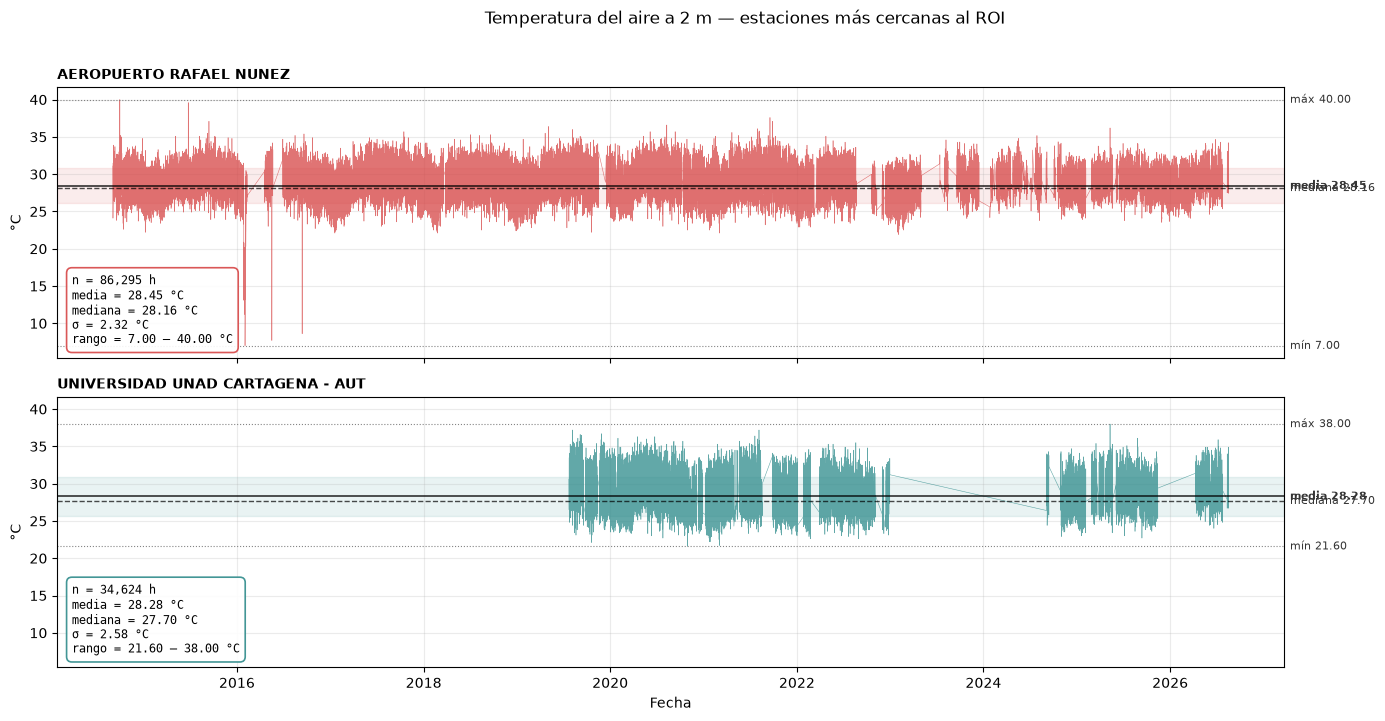

In [16]:
PALETA = ["#D64545", "#2E8B8B", "#5B7FBD", "#C08A2E"]
nombres = horaria["Estacion"].drop_duplicates().tolist()

stats = (
    horaria.groupby("Estacion")["temp"]
    .agg(n="size", media="mean", mediana="median", std="std", minimo="min", maximo="max")
    .round(2)
    .reindex(nombres)
)
display(stats)

fig, axes = plt.subplots(len(nombres), 1, figsize=(15, 3.6 * len(nombres)),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, nombre, color in zip(axes, nombres, PALETA):
    sub = horaria[horaria["Estacion"] == nombre]
    s = stats.loc[nombre]

    ax.plot(sub["FechaObservacion"], sub["temp"], lw=0.4, alpha=0.75, color=color)

    ax.axhspan(s["media"] - s["std"], s["media"] + s["std"],
               color=color, alpha=0.10, zorder=0)
    ax.axhline(s["media"], color="black", lw=1.2, ls="-", alpha=0.8)
    ax.axhline(s["mediana"], color="black", lw=1.0, ls="--", alpha=0.7)
    ax.axhline(s["minimo"], color="#666", lw=0.8, ls=":", alpha=0.8)
    ax.axhline(s["maximo"], color="#666", lw=0.8, ls=":", alpha=0.8)

    for val, txt, peso in [
        (s["media"],   f'media {s["media"]:.2f}',   "bold"),
        (s["mediana"], f'mediana {s["mediana"]:.2f}', "normal"),
        (s["minimo"],  f'mín {s["minimo"]:.2f}',    "normal"),
        (s["maximo"],  f'máx {s["maximo"]:.2f}',    "normal"),
    ]:
        ax.annotate(txt, xy=(1.0, val), xycoords=("axes fraction", "data"),
                    xytext=(4, 0), textcoords="offset points",
                    va="center", ha="left", fontsize=8, fontweight=peso, color="#333")

    caja = (f'n = {int(s["n"]):,} h\n'
            f'media = {s["media"]:.2f} °C\n'
            f'mediana = {s["mediana"]:.2f} °C\n'
            f'σ = {s["std"]:.2f} °C\n'
            f'rango = {s["minimo"]:.2f} – {s["maximo"]:.2f} °C')
    ax.text(0.012, 0.04, caja, transform=ax.transAxes, fontsize=8.5,
            va="bottom", ha="left", family="monospace",
            bbox=dict(boxstyle="round,pad=0.45", facecolor="white",
                      edgecolor=color, alpha=0.9, linewidth=1.2))

    ax.set_title(nombre, fontsize=10, loc="left", fontweight="bold")
    ax.set_ylabel("°C")
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Fecha")
fig.suptitle("Temperatura del aire a 2 m — estaciones más cercanas al ROI",
             fontsize=12, y=0.995)
plt.tight_layout(rect=[0, 0, 0.93, 0.98])
plt.show()

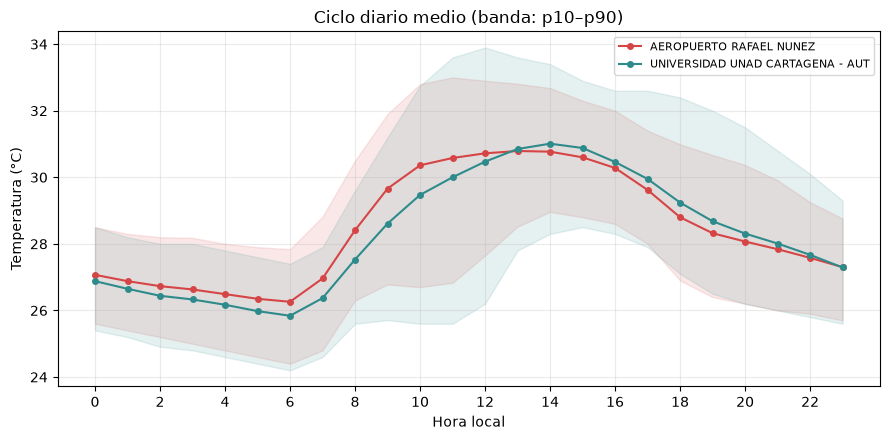

In [17]:
# Ciclo diario medio: comparación entre estaciones sobre una base homogénea
ciclo = (
    horaria.assign(hora=horaria["FechaObservacion"].dt.hour)
    .groupby(["Estacion", "hora"])["temp"]
    .agg(
        media="mean",
        p10=lambda x: x.quantile(0.10),
        p90=lambda x: x.quantile(0.90),
    )
    .round(2)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4.5))
for nombre, color in zip(nombres, PALETA):
    s = ciclo[ciclo["Estacion"] == nombre]
    ax.plot(s["hora"], s["media"], marker="o", ms=4, color=color, label=nombre[:34])
    ax.fill_between(s["hora"], s["p10"], s["p90"], color=color, alpha=0.12)

ax.set_xlabel("Hora local")
ax.set_ylabel("Temperatura (°C)")
ax.set_title("Ciclo diario medio (banda: p10–p90)")
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 10. Limitaciones a declarar en el manuscrito

**Ausencia de estaciones en el área de estudio.** Ninguna estación del IDEAM cae dentro de las cajas anidadas. La estación más próxima está a ~8.96 km del borde del ROI.
**Sesgo espacial de la red disponible.** Las dos estaciones más cercanas se ubican al oeste-suroeste (Cartagena de Indias).
**Representatividad.** Rafael Núñez es una estación aeroportuaria; UNAD Cartagena es una estación urbana.
**Heterogeneidad de muestreo.** Debe utilizarse la serie horaria u homogeneizada para comparaciones.